In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

def focal_loss_fixed(y_true, y_pred):
    gamma = 2.0
    alpha = 0.25
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    loss = alpha * tf.pow(tf.abs(y_true - y_pred), gamma) * bce
    return loss

model = load_model(
    '/content',
    custom_objects={'focal_loss_fixed': focal_loss_fixed}
)

In [ ]:
import numpy as np

img_path = '/content'
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(384, 384))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 384, 384, 3))
  warnings.warn(msg)


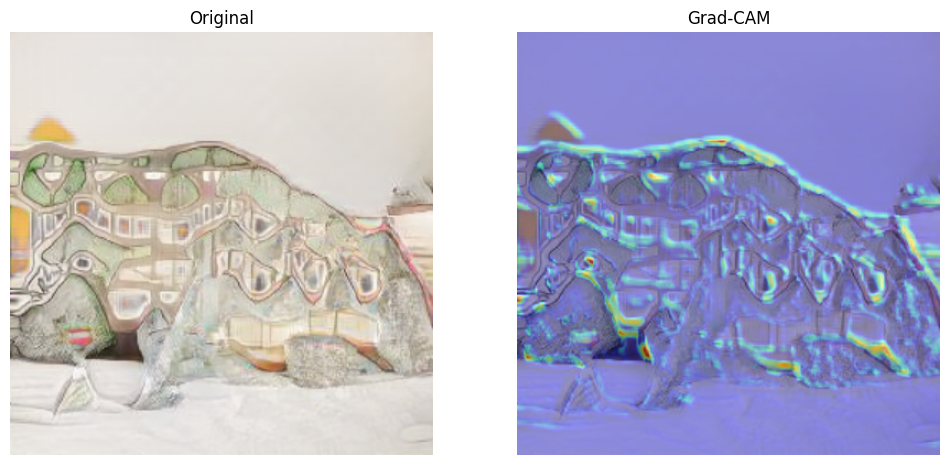

In [ ]:
# ------------------------------------------------------------------
# 3. GRAD-CAM FUNCTION
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        target = predictions[:, pred_index]

    grads = tape.gradient(target, conv_output)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]

    heatmap = tf.matmul(conv_output, pooled[..., tf.newaxis])
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    return heatmap

# ------------------------------------------------------------------
# 4. GET HEATMAP
# ------------------------------------------------------------------

heatmap = get_gradcam_heatmap(model, img_array, "conv2d_1")

# ------------------------------------------------------------------
# 5. OVERLAY ON ORIGINAL IMAGE
# ------------------------------------------------------------------
import cv2

img_original = cv2.imread(img_path)
img_original = cv2.resize(img_original, (384, 384))

heatmap_resized = cv2.resize(heatmap, (384, 384))
heatmap_resized = np.uint8(255 * heatmap_resized)
colormap = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(img_original, 0.6, colormap, 0.4, 0)

# ------------------------------------------------------------------
# 6. SHOW RESULT
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

# Grad-CAM Overlay
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis("off")

plt.show()




Found 2199 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


69/69 ━━━━━━━━━━━━━━━━━━━━ 858s 12s/step


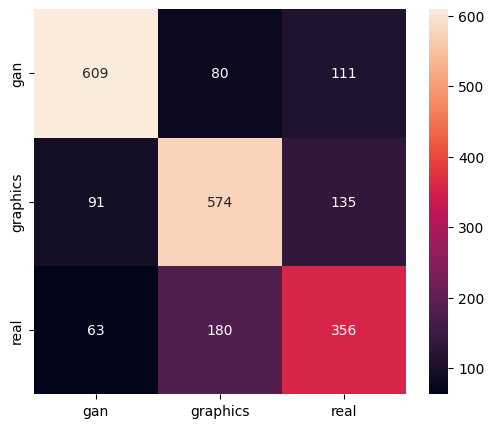

              precision    recall  f1-score   support

         gan       0.80      0.76      0.78       800
    graphics       0.69      0.72      0.70       800
        real       0.59      0.59      0.59       599

    accuracy                           0.70      2199
   macro avg       0.69      0.69      0.69      2199
weighted avg       0.70      0.70      0.70      2199



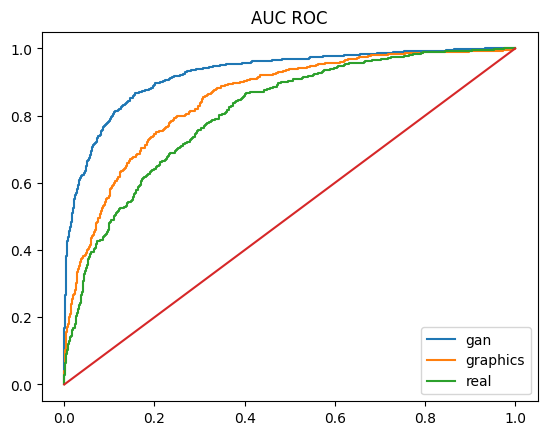

AttributeError: 'Functional' object has no attribute 'history'

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import tensorflow as tf

val_datagen = ImageDataGenerator(rescale=1./255)

val_gen = val_datagen.flow_from_directory(
    "/content",
    target_size=(384,384),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


model = load_model(
    "/content",
    custom_objects={"focal_loss_fixed": focal_loss_fixed}
)

y_true = val_gen.classes
labels = list(val_gen.class_indices.keys())
y_prob = model.predict(val_gen)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))

if y_prob.shape[1] == 2:
    fpr, tpr, _ = roc_curve(y_true, y_prob[:,1])
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.title("AUC ROC")
    plt.show()
else:
    for i in range(y_prob.shape[1]):
        fpr, tpr, _ = roc_curve(y_true == i, y_prob[:,i])
        plt.plot(fpr, tpr, label=labels[i])
    plt.plot([0,1],[0,1])
    plt.legend()
    plt.title("AUC ROC")
    plt.show()

history = model.history.history
plt.plot(history["val_accuracy"])
plt.title("Val Accuracy")
plt.show()

plt.plot(history["val_loss"])
plt.title("Val Loss")
plt.show()

img_path = val_gen.filepaths[0]
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
x = tf.keras.preprocessing.image.img_to_array(img)
x = np.expand_dims(x, axis=0)

grad_model = tf.keras.models.Model([model.inputs], [model.layers[-3].output, model.output])
with tf.GradientTape() as t:
    conv_out, preds = grad_model(x)
    idx = np.argmax(preds[0])
    loss = preds[:, idx]

grads = t.gradient(loss, conv_out)
w = np.mean(grads, axis=(0,1,2))
cam = np.dot(conv_out[0], w)
cam = np.maximum(cam, 0)
cam = cam / cam.max()

plt.imshow(tf.keras.preprocessing.image.load_img(img_path))
plt.imshow(cam, cmap="jet", alpha=0.4)
plt.title("Grad-CAM")
plt.show()


Saving freeFoto_01_25_3_prev.jpg to freeFoto_01_25_3_prev.jpg
Uploaded: freeFoto_01_25_3_prev.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction: real
Confidence: 47.40 %
Using Grad-CAM layer: conv2d_1


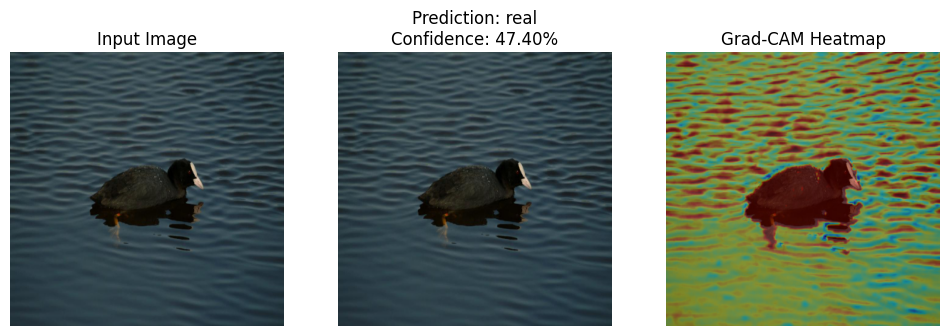

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model(
    '/content/drive/MyDrive/phase7_balanced_gan_fix.keras',
    custom_objects={'focal_loss_fixed': focal_loss_fixed}
)

class_names = ["gan", "graphic", "real"]

# ------------------------------------------------
# Upload image
# ------------------------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded:", filename)

img = image.load_img(filename, target_size=(384, 384))
img_array = image.img_to_array(img)
img_array = img_array.astype("float32") / 255.0
input_tensor = np.expand_dims(img_array, axis=0)

# ------------------------------------------------
# Prediction
# ------------------------------------------------
pred = model.predict(input_tensor)[0]
pred_class_idx = np.argmax(pred)
confidence = pred[pred_class_idx] * 100

print(f"Prediction: {class_names[pred_class_idx]}")
print(f"Confidence: {confidence:.2f} %")

# ------------------------------------------------
# Find last CONV layer for Grad-CAM
# ------------------------------------------------
last_conv_layer = None
for layer in reversed(model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer = layer
            break
    except:
        continue

if last_conv_layer is None:
    raise ValueError("No convolution layer found for Grad-CAM!")

print("Using Grad-CAM layer:", last_conv_layer.name)

# ------------------------------------------------
# Build Grad-CAM model
# ------------------------------------------------
grad_model = tf.keras.models.Model(
    [model.inputs],
    [last_conv_layer.output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_tensor)
    loss = predictions[:, pred_class_idx]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
heatmap = np.maximum(heatmap, 0)
heatmap /= heatmap.max()

# ------------------------------------------------
# Resize heatmap to original size
# ------------------------------------------------
heatmap = cv2.resize(heatmap, (384, 384))
heatmap = np.uint8(255 * heatmap)

# apply color map
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# overlay heatmap on original
original_img = cv2.imread(filename)
original_img = cv2.resize(original_img, (384, 384))
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

# ------------------------------------------------
# Display results
# ------------------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(original_img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title(f"Prediction: {class_names[pred_class_idx]}\nConfidence: {confidence:.2f}%")
plt.imshow(original_img)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Grad-CAM Heatmap")
plt.imshow(superimposed_img)
plt.axis("off")

plt.show()